<a href="https://colab.research.google.com/github/Nishanta04/Deep-Learning/blob/main/ANDLogic_Preceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **AND Logic Preceptron with 2 inputs (2D)**

In [15]:
X = np.array([[0,0,0],[0,1,0],[1,0,0],[1,1,1]])
X = pd.DataFrame(X)

In [16]:
X

,0,1,2
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


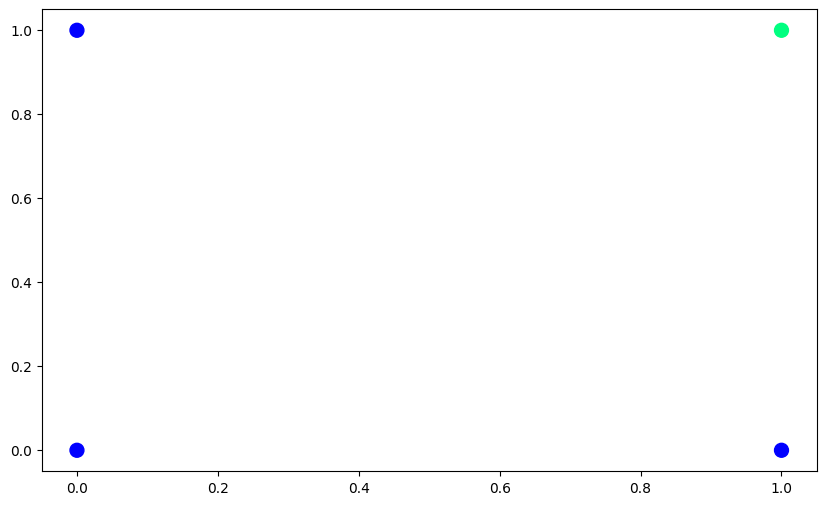

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=X.iloc[:,-1],cmap='winter',s=100)

In [18]:
a = X.iloc[:,0:2]
b = X.iloc[:,-1]

In [19]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [20]:
p.fit(a,b)

Perceptron()

In [21]:
# Weights (w1 and w2)
p.coef_

array([[2., 2.]])

In [22]:
# Bias
p.intercept_

array([-2.])

In [23]:
m = -(p.coef_[0][0]/p.coef_[0][1])
c = -(p.intercept_[0]/p.coef_[0][1])

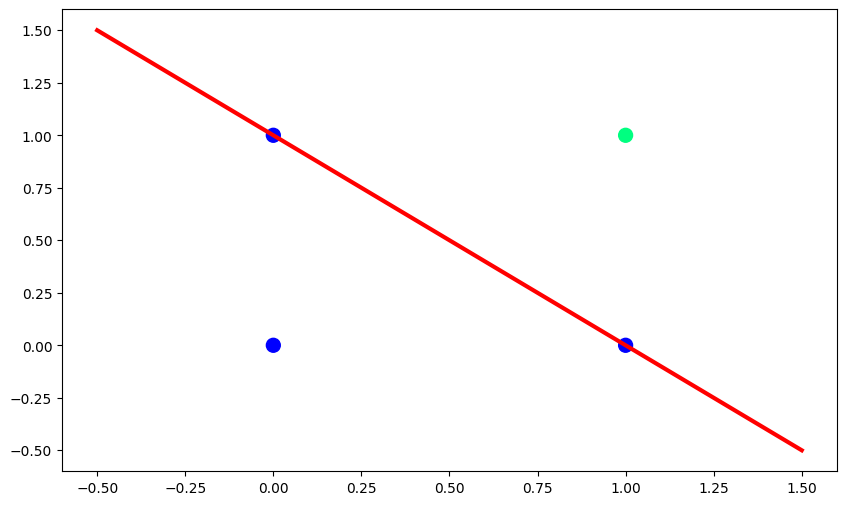

In [24]:
x_input = np.linspace(-0.5,1.5,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=X.iloc[:,-1],cmap='winter',s=100)

# plt.ylim(-0.5,1.5)

# **AND Logic Preceptron with 3 inputs (3D)**

In [35]:
X = np.array([[0,0,0,0],
              [0,0,1,0],
              [0,1,0,0],
              [0,1,1,0],
              [1,0,0,0],
              [1,0,1,0],
              [1,1,0,0],
              [1,1,1,1],])
X = pd.DataFrame(X)

In [36]:
a_new = X.iloc[:, :3]
b_new = X.iloc[:, 3]

print("New 3-input X:\n", a_new)
print("\nNew 3-input y:\n", b_new)

New 3-input X:
    0  1  2
0  0  0  0
1  0  0  1
2  0  1  0
3  0  1  1
4  1  0  0
5  1  0  1
6  1  1  0
7  1  1  1

New 3-input y:
 0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
Name: 3, dtype: int64


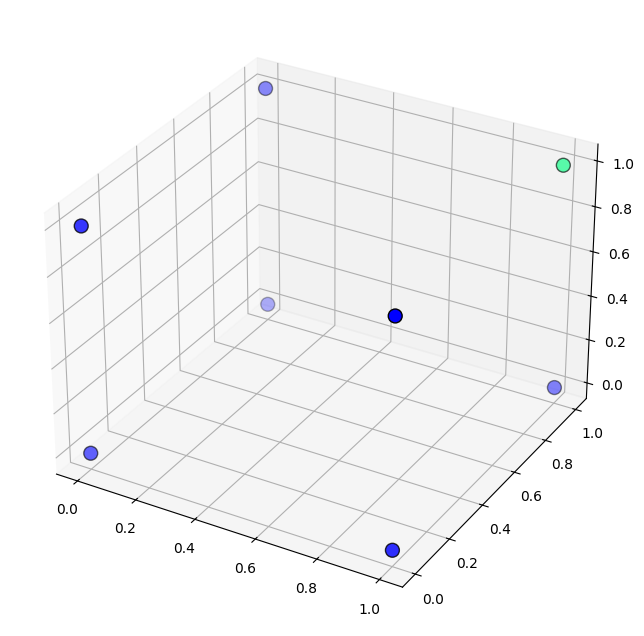

In [37]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=b_new, cmap='winter', s=100, edgecolors='k')
plt.show()

In [38]:
a = X.iloc[:,0:3]
b = X.iloc[:,-1]

In [39]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [40]:
p.fit(a,b)

Perceptron()

In [41]:
# Weights (w1 and w2)
p.coef_

array([[3., 2., 1.]])

In [42]:
# Bias
p.intercept_

array([-3.])

In [44]:
import plotly.graph_objects as go

# Weights
w1 = p.coef_[0][0]
w2 = p.coef_[0][1]
w3 = p.coef_[0][2]
c = p.intercept_[0]

# Create x and y values
x_input = np.linspace(-0.5, 1.5, 100)
y_input = np.linspace(-0.5, 1.5, 100)

# Create grid
xx, yy = np.meshgrid(x_input, y_input)

# Calculate z
zz = -(w1 * xx + w2 * yy + c) / w3

# Create interactive 3D plot
fig = go.Figure()

# Decision boundary plane
fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.5,
    name='Decision Boundary'
))

# Data points
fig.add_trace(go.Scatter3d(
    x=X.iloc[:, 0],
    y=X.iloc[:, 1],
    z=X.iloc[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=X.iloc[:, -1],
        colorscale='bluered'
    ),
    name='Data Points'
))

# Labels
fig.update_layout(
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='X3'
    ),
    width=900,
    height=700
)

fig.show()